# YouTube Thumbnail Maker

In [10]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict
from langgraph.types import Send, interrupt, Command
import subprocess
from openai import OpenAI
import textwrap
from langchain.chat_models import init_chat_model
import operator
from typing_extensions import Annotated
import base64
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

llm = init_chat_model("openai:gpt-4o-mini",)

class State(TypedDict):
    video_file : str
    audio_file : str
    transcription : str
    summaries : Annotated[list[str], operator.add]
    thumbnail_prompts : Annotated[list[str], operator.add]
    thumbnail_sketches : Annotated[list[bytes], operator.add]
    final_summary : str
    user_feedback : str
    chosen_prompt : str

In [3]:
def extract_audio(state: State):
    output_file = state["video_file"].replace("mp4", "mp3")
    command = [
        "ffmpeg",
        "-i",
        state["video_file"],
        "-filter:a",
        "atempo=2.0",
        "-y",
        output_file

    ]

    subprocess.run(command)

    return {"audio_file": output_file}

def transcribe_audio(state: State):
    client = OpenAI()
    with open(state["audio_file"], "rb") as audio_file:

        transcription = client.audio.transcriptions.create(
            model="whisper-1",
            response_format="text",
            file=audio_file,
        )

        return {
            "transcription": transcription
        }
    

def dispatch_summarizers(state: State):
    transcription = state["transcription"]
    chunks = []

    for i, chunk in enumerate(textwrap.wrap(transcription, 500)):
        chunks.append(
            {
                "id": i + 1,
                "chunk": chunk
            }
        )
    return [
        Send(
            "summarize_chunk",
            chunk
        ) for chunk in chunks
    ]

def summarize_chunk(chunk):
    chunk_id = chunk["id"]
    chunk_content = chunk["chunk"]

    print(f"Summarizing chunk {chunk_id}...")

    response = llm.invoke(
        f"""
        Summarize following content in Korean.
        자연스럽고 이해하기 쉬운 한글 요약본으로 작성해줘.

        Text: {chunk_content}
        """
    )

    summary = f"[Chunk {chunk_id}]: {response.content}"

    return {
        "summaries" : [summary]
    }

def mega_summary(state : State):
    all_summaries = "\n".join(state["summaries"])

    prompt = f"""

    Summarize the following summaries into one summary in Korean.
    자연스럽고 이해하기 쉬운 한글 요약본으로 작성해줘.

    Invidiual summaries:

    {all_summaries}
    """
    response = llm.invoke(prompt)

    return {
        "final_summary": response.content
    }

def dispatch_artists(state: State):
    return[
        Send(
            "generate_thumbnails",{
                "id": i,
                "summary" : state["final_summary"]
            }
        ) for i in range(5)
    ]


def generate_thumbnails(args):
    id = args["id"]
    summary = args["summary"]

    prompt = f"""
    Bseed on this video summary, create a detialed visual prompt for a youtube thumbnail. 

    Create a detailed prompt for generating a thumbnail image that would attract viewers. Include

       - Main visual elements
       - Color scheme
       - Text overlay suggestions( Korean )
       - Overall composition

    Summary: {summary}

    """

    response = llm.invoke(prompt)

    thumbnail_prompt = response.content

    client = OpenAI()

    result = client.images.generate(
        model="gpt-image-1.5",
        prompt=thumbnail_prompt,
        quality="low",
        moderation="low",
        size="auto",
    )

    image_bytes = base64.b64decode(result.data[0].b64_json)

    file_name = f"thumbnail_{id}.png"

    with open(file_name, "wb") as image_file:
        image_file.write(image_bytes)

        return {
            "thumbnail_prompts": [thumbnail_prompt],
            "thumbnail_sketches": [file_name]
        }
    
def human_feedback(state: State):
    answer = interrupt({
        "chosen_thumbnail" : "가장 마음에 드는 썸네일을 선택해주세요.",
        "feedback" : "선택한 썸네일에 대한 피드백을 남겨주세요."
    })
    user_feedback = answer["user_feedback"]
    chosen_prompt = answer["chosen_prompt"]

    return {
        "user_feedback": user_feedback,
        "chosen_prompt": state["thumbnail_prompts"][chosen_prompt]
    }

def generate_hd_thumbnail(state: State):
    chosen_prompt = state["chosen_prompt"]
    user_feedback = state["user_feedback"]

    prompt = f"""
    You are a professional Youtube thumbnail designer.
    Take this orignal thumbnail prompt and user feedback to create an improved thumbnail prompt that would attract more viewers.

    Original thumbnail prompt: {chosen_prompt}
    User feedback: {user_feedback}
    

    Create an enhanced prompt that:

        1. Maintains the core concept from the otiginal prompt.
        2. Specifically addresses the user feedback to improve the thumbnail's appeal.
        3. Adds professional Youtube thumbnail specifications

            - High contrast and bold visual elements
            - Clear focal points that draw eye
            - Optimal text placement and readability with generous padding from edges

            _ IMPORTANT : Always ensure adequate white space/padding between any text and the image borders

    """

    response = llm.invoke(prompt)

    final_thumbnail_prompt = response.content

    client = OpenAI()

    result = client.images.generate(
        model="gpt-image-1.5",
        prompt=final_thumbnail_prompt,
        quality="high",
        moderation="low",
        size="auto",
    )


    image_bytes = base64.b64decode(result.data[0].b64_json)

    with open("final_thumbnail.png", "wb") as image_file:
        image_file.write(image_bytes)






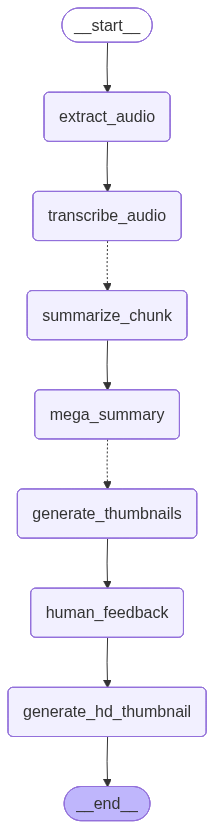

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("extract_audio", extract_audio)
graph_builder.add_node("transcribe_audio", transcribe_audio)
graph_builder.add_node("summarize_chunk", summarize_chunk)
graph_builder.add_node("mega_summary", mega_summary)
graph_builder.add_node("generate_thumbnails", generate_thumbnails)
graph_builder.add_node("human_feedback", human_feedback)
graph_builder.add_node("generate_hd_thumbnail", generate_hd_thumbnail)

graph_builder.add_edge(START, "extract_audio")
graph_builder.add_edge("extract_audio", "transcribe_audio")
graph_builder.add_conditional_edges("transcribe_audio", dispatch_summarizers, ["summarize_chunk"])
graph_builder.add_edge("summarize_chunk", "mega_summary")
graph_builder.add_conditional_edges("mega_summary", dispatch_artists, ["generate_thumbnails"])
graph_builder.add_edge("generate_thumbnails", "human_feedback")
graph_builder.add_edge("human_feedback", "generate_hd_thumbnail")
graph_builder.add_edge("generate_hd_thumbnail", END)

graph = graph_builder.compile(checkpointer=memory)


graph


In [5]:
config = {
    "configurable" : {
        "thread_id" : "1"
    }
}

In [6]:
result =graph.invoke(
    {
        "video_file": "study.mp4",
    }, 
    config=config
)


ffmpeg version 8.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 21.0.0 (clang-2100.0.123.102)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.100 / 60. 26.100
  libavcodec     62. 28.100 / 62. 28.100
  libavformat    62. 12.100 / 62. 12.100
  libavdevice    62.  3.100 / 62.  3.100
  libavfilter    11. 14.100 / 11. 14.100
  libswscale      9.  5.100 /  9.  5.100
  libswresample   6.  3.100 /  6.  3.100
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'study.mp4':
  Metadata:
    major_brand     : isom
    minor_version   : 512
    compatible_brands: isomiso2avc1mp41
    title           : 돈 픽처스 경제

Summarizing chunk 1...Summarizing chunk 2...

Summarizing chunk 3...
Summarizing chunk 4...
Summarizing chunk 5...
Summarizing chunk 6...


In [7]:
result

{'video_file': 'study.mp4',
 'audio_file': 'study.mp3',
 'transcription': '자 빨리 사인하세요 사인 함부로 하는 거 아니라고 그랬... 아이 그쪽 화폐는 이제 달러랑 연동되는 거에 동의하시라고요 제가 이걸 왜 해요? 아이 그쪽 지금 전쟁하느라 상태도 안 좋고 무기 산다고 우리한테 금도 다 팔아넘겼잖아요 흐흠 그렇긴 한데 대신 달러가격도 금이랑 고정시켜놓고 언제든지 달러 가져오면 금이랑 바꿔 드릴게요 꼭 바꿔 주셔야 돼요 저 못 믿어요 아뇨 그게 아니... 카카 베트남 전쟁인데 돈이 더 필요합니다 어어 써 옥지 예산도 더 필요... 어어 써 저 집 강아지 사료도 더 필요... 어어 쓰라니까 미국이 저렇게 돈이 많아? 어? 그럼 우리 돈은? 큰일 났습니다 애들이 달러 줄 텐가 금 다시 내놓으라고 난리입니다 와 진짜 큰일 났네 그러니까 이제 돈 그만 쓰... 아니... 쟤들이 큰일 났다고? 네? 응 달러랑 금이랑 안 바꿔주면 그만이야 자 조금만 더... 미국이 약속했다고? 어우 금값 오를게 또로롱? 카카 이런 식이면 우리 달러를 더 이상 안 쓰려고 할 겁니다 그럼 모든 나라들이 써야 하는 소개를 강제로 달러로만 사기하면 어때? 잠시 후 You need dollar I need 군사 Okay? Deal? Deal 저 돈 좀 더 찍어내볼까? 벌 벌 사 이거는 베트남 전쟁한테 쓰고 요거는 복지 정책에다가 어이 저기요 금 가지고 있는 만큼만 돈 줄기로 약속했잖아요? 했었죠 근데 그쪽은 달러를 너무 많이 찍는 거 같은데 아 그래서요? 달러를 못 믿겠으니까 그냥 금 다시 가져갈게 안 돼 안 바꿔줘 바꿀 생각 없어 돌아가 카카 이런 식으로 달러를 계속 찍으려면 물가가 오를 겁니다 빨리 금리 올려서 물가를 잘 봐 사람이 3명 모이면 그중에 한 명은 범인이래 일단 나는 물가 안 올렸거든 너도 안 올렸는데 오? 차차차차야? 내가 범인이었네 물가가 올라서 문제는 못 올리게 막으면 되지 뭘 금리까지 건드리냐 좌회전의 생각은 어떠

In [8]:
snapshot = graph.get_state(config)

snapshot.interrupts

(Interrupt(value={'chosen_thumbnail': '가장 마음에 드는 썸네일을 선택해주세요.', 'feedback': '선택한 썸네일에 대한 피드백을 남겨주세요.'}, id='f52529ad8761c212e6518d92a3d1a013'),)

In [11]:
response = {
    "user_feedback": "한글 폰트가 뭉게져 보이는데 좀 더 선명한 폰트로 바꿔주면 좋겠어요. 캐릭터는 좀 더 귀여운 느낌으로 바꿔주면 좋겠어요.",
    "chosen_prompt": 4
}

snapshot = graph.invoke(
    Command(resume=response),
    config=config
)
